## Quest 1: Logistic Regression

In [15]:
import numpy as np
import matplotlib.pyplot as plt
n = 50
mx1 = 1
vx1 = 2
my1 = 1
vy1 = 2
mx2 = 10
vx2 = 2
my2 = 10
vy2 = 2

In [16]:
def Data_Generator(U, V, Mean, Variance): #Function from HW02
  X = np.sqrt(-2 * np.log(U)) * np.cos(2 * np.pi * V) #cos也可改成sin, 亦為隨機
  X = X * np.sqrt(Variance) + Mean
  return X[0]

In [17]:
def Dataset_Generate(n, mx, vx, my, vy):
  dataset = []
  for i in range(n):
    Ux = np.random.rand(1)
    Vx = np.random.rand(1)
    Uy = np.random.rand(1)
    Vy = np.random.rand(1)

    x = Data_Generator(Ux, Vx, mx, vx)
    y = Data_Generator(Uy, Vy, my, vy)
    dataset.append([x, y])
  return np.array(dataset) #回傳大小(n x 2)

In [18]:
D1 = Dataset_Generate(n, mx1, vx1, my1, vy1) #Data cluster 1
D2 = Dataset_Generate(n, mx2, vx2, my2, vy2) #Data cluster 2
D1 = np.hstack((D1, np.zeros((n, 1)))) #加入0的label (D1.shape=n x 3)
D2 = np.hstack((D2, np.ones((n, 1)))) #加入1的label (D2.shape=n x 3)
D = np.vstack((D1,D2)) #D.shape = 2n x 3
#將D做出(x,y,label)
X = D[:,0:2] #(x,y)為輸入(X), label為輸出(Y)
Y = D[:,2]
#分離出輸入和輸出
X = np.hstack((np.ones((X.shape[0], 1)), X)) #X新增bias term

In [19]:
def sigmoid(x): #Logistic Regression.
  return 1/(1+np.exp(-x))

In [20]:
def train_with_gradient_descent(x,y,max_iter=10000,lr=0.001):
  theta = np.zeros(x.shape[1])
  for i in range(max_iter):
    #theta(t) = theta(t-1) - lr*delta(J(theta))
    y_hat = sigmoid(x @ theta)
    error = y - y_hat
    grad = x.T @ error #delat(J(theta))
    theta += lr * grad

  return theta

In [21]:
def train_with_newton_cg(x,y,max_iter=10000,lr=0.001):
  theta = np.zeros(x.shape[1])
  for i in range(max_iter):
    y_hat = sigmoid(X @ theta)
    R = np.diag(y_hat * (1 - y_hat))
    H = x.T @ R @ x #Hessian Matrix
    g = x.T @ (y - y_hat) #delta(f)
    if abs(np.linalg.det(H))<1e-8: #H is singular -> steepest descent
      delta = g*lr
    else:
      delta = np.linalg.inv(H) @ g #Inverse(H)*g
    theta += delta

  return theta

In [22]:
def predict(X, theta):
    probs = sigmoid(X @ theta) #sigmoid當indicator
    return (probs >= 0.5).astype(int)

def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1)) #猜1答1 -> True Positive
    TN = np.sum((y_true == 0) & (y_pred == 0)) #猜0答0 -> True Negative
    FP = np.sum((y_true == 0) & (y_pred == 1)) #猜1答0 -> False Positive
    FN = np.sum((y_true == 1) & (y_pred == 0)) #猜0答1 -> True Positive
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    return TP, TN, FP, FN, sensitivity, specificity


Gradient Descent:
w: (theta)
 [-7.51918407  0.83858601  0.72949643]
Confusion Matrix:                                                                                   
                    |           Predict_cluster_1            |           Predict_cluster_2            
In_cluster_1        |                   50                   |                   0                    
In_cluster_2        |                   0                    |                   50                   
Sensitivity, Specificity =  (np.float64(1.0), np.float64(1.0))

Newton-CG:
w: (theta)
 [-17.62407887   1.5998625    1.74282931]
Confusion Matrix:                                                                                   
                    |           Predict_cluster_1            |           Predict_cluster_2            
In_cluster_1        |                   50                   |                   0                    
In_cluster_2        |                   0                    |                   50    

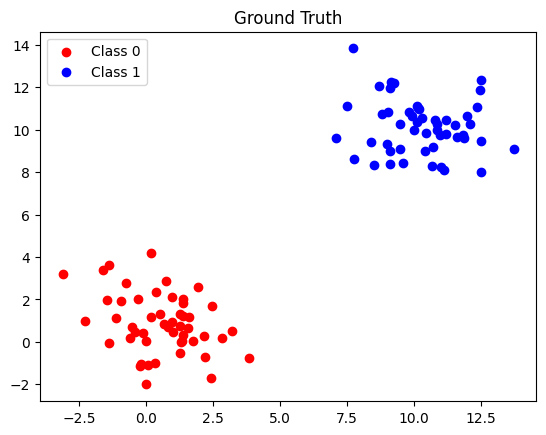

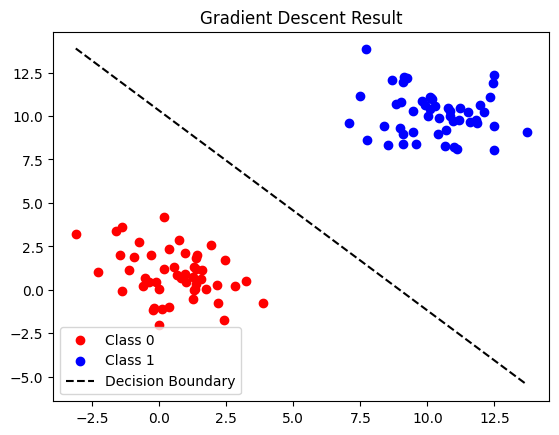

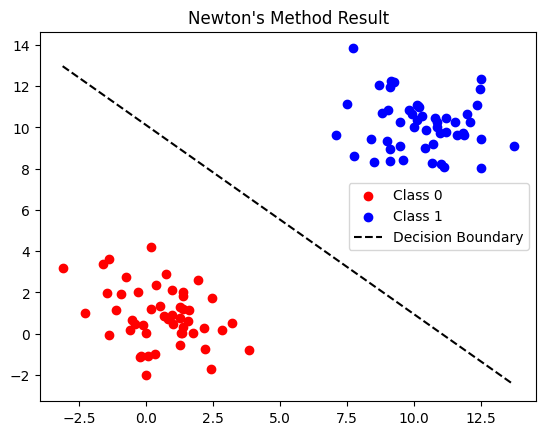

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# === 函數：畫出分類結果 ===
def plot_result(X, y, theta, title):
    plt.figure()
    plt.title(title)
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red', label='Class 0') #畫(label=0時)的(x,y)
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='Class 1') #畫(label=1時)的(x,y)

    # Decision boundary
    x_vals = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)
    y_vals = -(theta[0] + theta[1]*x_vals) / theta[2]

    plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

    plt.legend()
    plt.show()


#訓練+預測
theta_gd = train_with_gradient_descent(X, Y)
theta_newton = train_with_newton_cg(X, Y)

Predict_gd = predict(X, theta_gd)
Predict_newton = predict(X, theta_newton)

confusion_matrix_gd = confusion_matrix(Y, Predict_gd)
confusion_matrix_newton = confusion_matrix(Y, Predict_newton)

#output info
Bit_Length = 100

print("Gradient Descent:")
print("w: (theta)\n", theta_gd)
print("Confusion Matrix:".ljust(Bit_Length))
print("{:<20}|{:^40}|{:^40}".format("", "Predict_cluster_1", "Predict_cluster_2"))
print("{:<20}|{:^40}|{:^40}".format("In_cluster_1", confusion_matrix_gd[0], confusion_matrix_gd[2]))
print("{:<20}|{:^40}|{:^40}".format("In_cluster_2", confusion_matrix_gd[3], confusion_matrix_gd[1]))
print("Sensitivity, Specificity = ", confusion_matrix_gd[-2:])

print("\nNewton-CG:")
print("w: (theta)\n", theta_newton)
print("Confusion Matrix:".ljust(Bit_Length))
print("{:<20}|{:^40}|{:^40}".format("", "Predict_cluster_1", "Predict_cluster_2"))
print("{:<20}|{:^40}|{:^40}".format("In_cluster_1", confusion_matrix_newton[0], confusion_matrix_newton[2]))
print("{:<20}|{:^40}|{:^40}".format("In_cluster_2", confusion_matrix_newton[3], confusion_matrix_newton[1]))
print("Sensitivity, Specificity = ", confusion_matrix_newton[-2:])


# === Ground Truth 圖 (單獨畫) ===
plt.figure()
plt.title("Ground Truth")
plt.scatter(X[Y==0][:, 1], X[Y==0][:, 2], color='red', label='Class 0')
plt.scatter(X[Y==1][:, 1], X[Y==1][:, 2], color='blue', label='Class 1')
plt.legend()
plt.show()

# === 模型結果圖 ===
plot_result(X[:, 1:], Predict_gd, theta_gd, "Gradient Descent Result")
plot_result(X[:, 1:], Predict_newton, theta_newton, "Newton's Method Result")


## Quest 2: EM algo

In [24]:
import struct
import numpy as np
from timeit import default_timer as timer

def load_mnist_images(filename,image_file):
    with open(filename, 'rb') as f:
        if image_file: #影像檔
          # 讀取 header
          magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
          #前4個分別為magic, num_images, rows, cols (pdf上的unsigned byte從17開始)
          # 讀取影像資料
          image_data = f.read(num_images * rows * cols)
          images = np.frombuffer(image_data, dtype=np.uint8) #Buffer -> Numpy Array
          images = images.reshape((num_images, rows, cols)) #確保shape
          return images

        else: #標籤檔
          # 讀取 header
          magic, num_labels = struct.unpack('>II', f.read(8))
          #前2個分別為magic, num_images (pdf上的unsigned byte從9開始)
          label_data = f.read(num_labels)
          labels = np.frombuffer(label_data, dtype=np.uint8) #Buffer -> Numpy Array
          return labels

train_images = load_mnist_images('train-images.idx3-ubyte__',True)
train_labels = load_mnist_images('train-labels.idx1-ubyte__',False)

In [25]:
print(train_images.shape)
print(train_labels.shape)

(60000, 28, 28)
(60000,)


In [26]:
def Convert_Pic(Pic_Set):
    N = Pic_Set.shape[0]
    Pic_Set = Pic_Set.reshape(N, -1)
    Pic_Set = (Pic_Set > 127).astype(np.uint8) #換成0或1
    return Pic_Set
train_images = Convert_Pic(train_images)

In [27]:
def likelihood_calculation(x, mu): #實際上為log likelihood (因此後面log(A*B) -> logA + logB)
    eps = 1e-10
    Log_P = np.sum(x * np.log(mu + eps) + (1 - x) * np.log(1 - mu + eps))
    return Log_P

def E_STEP_Deno(x, mu, pi): #分母計算
    #using log-sum-exp
    eps = 1e-10
    log_terms = np.zeros(10)
    for k in range(10):
        log_terms[k] = np.log(pi[k] + eps) + likelihood_calculation(x, mu[k])

    m = np.max(log_terms)
    log_deno = m + np.log(np.sum(np.exp(log_terms - m)))
    return log_deno

def E_STEP(x, mu, pi):
    eps = 1e-10
    log_deno = E_STEP_Deno(x, mu, pi)
    log_r = np.zeros(10)
    for k in range(10):
        log_r[k] = np.log(pi[k] + eps) + likelihood_calculation(x, mu[k]) - log_deno
    r = np.exp(log_r)
    return r

#前面Estep皆針對單一pixel, 後面Mstep針對全部圖的所有pixel
def M_STEP(X,R):
  N = X.shape[0]
  eps = 1e-10
  Nk = np.sum(R, axis=0)
  pi = Nk/N
  mu = np.zeros((10,784))

  for k in range(10):
    mu[k] = (R[:, k][:, None] * X).sum(axis=0) / (Nk[k] + eps)
    mu[k] = np.clip(mu[k], eps, 1 - eps)
  return pi,mu #回傳新的status coefficient

In [28]:
K = 10
N, D = train_images.shape
pi = np.ones(K) / K
mu = np.random.rand(K, D)
R = np.zeros((N, K))
max_iter = 10

def print_imagination(mu, k):
    print(f"class {k}:")
    img = (mu.reshape(28, 28) >= 0.5).astype(int) #產出1或0
    for row in img:
        print(" " + " ".join(map(str, row.tolist())))

def confusion_one_vs_all(y_true, y_pred, d):
    tp = np.sum((y_true == d) & (y_pred == d))
    fn = np.sum((y_true == d) & (y_pred != d))
    fp = np.sum((y_true != d) & (y_pred == d))
    tn = np.sum((y_true != d) & (y_pred != d))
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0 #分母不可為0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0 #理由同上
    return tp, fn, fp, tn, sens, spec

pre_Log_likilihood = -np.inf
for iteration in range(max_iter):
    #E step
    for n in range(N):
        R[n] = E_STEP(train_images[n], mu, pi)
    #M step
    pi, mu = M_STEP(train_images, R)

    for i in range(10):
      print_imagination(mu[i],i)

    Log_likelihood = 0
    for n in range(N):
        Log_likelihood += E_STEP_Deno(train_images[n], mu, pi)
    Log_likelihood = Log_likelihood / N
    Total_Diff = Log_likelihood - pre_Log_likilihood
    pre_Log_likilihood = Log_likelihood
    print("No. of Iteration: %d, Difference: %.3f"%(iteration, Total_Diff))

pred_k = np.argmax(R,axis=1)

k_to_digit = np.zeros(10, dtype=int) #修正"預測為class n但實際出來是class m之情況"
for k in range(10): #針對10個digit
  idx = (pred_k == k) #60000張照片中最大預測為k者的T/F table
  if np.sum(idx)==0: #沒人預測值為k
    k_to_digit[k]=0
    continue
  labels, counts = np.unique(train_labels[idx], return_counts=True) #預測為idx者未必train label為idx
  k_to_digit[k] = labels[np.argmax(counts)] #找出群中最大標籤者(比如class2最多人對應到digit 6則class2即為digit 6)

print("\n=== Labeled class ===")
for d in range(10):
    # 找出對應到該 digit 的 cluster
    cluster_indices = [k for k, digit in enumerate(k_to_digit) if digit == d]
    if len(cluster_indices) == 0:
        continue
    best_k = cluster_indices[0]  # 若有多個群對應同一數字，取第一個即可
    print_imagination(mu[best_k], d)

pred_digit = np.array([k_to_digit[k] for k in pred_k])

for d in range(10):
    tp, fn, fp, tn, sens, spec = confusion_one_vs_all(train_labels, pred_digit, d)
    print(f"\nConfusion Matrix {d}:")
    print("                        Predict number {:<1}        Predict not number {:<1}".format(d, d))
    print(" Is number {:<1}            {:>10}                   {:>10}".format(d, tp, fn))
    print(" Isn't number {:<1}         {:>10}                   {:>10}".format(d, fp, tn))
    print(f"Sensitivity (Successfully predict number {d}): {sens:.5f}")
    print(f" Specificity (Successfully predict not number {d}): {spec:.5f}")

class 0:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0